<a href="https://colab.research.google.com/github/binsue0/.github/blob/main/DL_day3/3_3_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 규제(Regularization) 기법 — FashionMNIST 실습

신경망의 목적은 학습 데이터를 외우는 것이 아니라, 학습 중 보지 못한 데이터에도 잘 작동하는 것입니다. 이 실습에서는 동일한 MLP에 Batch Normalization과 Dropout을 각각 적용하고 학습·평가 loss를 비교합니다.

### 학습 목표

- 과적합과 일반화 오차의 의미를 이해한다.
- Batch Normalization과 Dropout의 학습·평가 시 동작 차이를 설명한다.
- 동일한 구조의 세 모델을 공정하게 비교하는 방법을 익힌다.
- loss 곡선으로 underfitting과 overfitting의 신호를 해석한다.
- 현재 예제 코드의 단순화와 구현상 주의점을 구분한다.


## 실습 개요

같은 4층 MLP에 세 가지 설정을 적용합니다.

| 모델 | 추가한 요소 | 주된 역할 |
|---|---|---|
| **Net** | 없음 | 비교 기준선 |
| **NetBN** | Batch Normalization | activation scale을 안정화하여 최적화를 돕고, 경우에 따라 일반화에도 도움 |
| **NetDO** | Dropout | 학습 중 일부 activation을 무작위로 제거하여 공동 적응을 줄임 |

정규화의 일반적인 목적은 모델 복잡도를 직접 또는 간접적으로 제한해 **train 성능과 unseen data 성능 사이의 차이**, 즉 generalization gap을 줄이는 것입니다.

> Batch Normalization은 흔히 regularization 단원에서 함께 다루지만, 본래 목적은 최적화 안정화에 더 가깝습니다. 고전적인 regularization에는 L1/L2 penalty(`weight_decay`), early stopping, data augmentation 등이 있습니다.


## 1. 준비 — 라이브러리와 FashionMNIST

FashionMNIST를 내려받고 mini-batch 단위로 모델에 공급할 수 있도록 준비합니다. 데이터 형태와 label의 의미를 확인한 뒤 모델을 정의합니다.


### 라이브러리 구성

- `torch`, `torch.nn`, `torch.nn.functional`: 모델과 layer, activation, 손실함수를 구성합니다.
- `torch.optim`: Adam optimizer와 learning-rate scheduler를 제공합니다.
- `DataLoader`: dataset을 mini-batch로 나누어 반복 가능하게 만듭니다.
- `torchvision.datasets`, `transforms`: FashionMNIST와 tensor 변환을 제공합니다.
- `matplotlib`: image sample과 loss curve를 시각화합니다.

`%matplotlib inline`은 Jupyter 환경에서 그래프를 셀 아래에 표시하는 magic command입니다.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader

from torchvision import datasets, transforms

from torchsummary import summary

### FashionMNIST 불러오기

FashionMNIST는 28×28 grayscale 의류 이미지의 10-class 분류 dataset입니다. 학습용 60,000장과 테스트용 10,000장으로 구성됩니다.

`ToTensor()`는 이미지를 `(channel, height, width)` 형태의 tensor로 바꾸고 pixel 값을 `[0, 1]` 범위로 변환합니다. 따라서 한 샘플의 형태는 `(1, 28, 28)`입니다.

| Label | Class | Label | Class |
|---:|---|---:|---|
| 0 | T-shirt/top | 5 | Sandal |
| 1 | Trouser | 6 | Shirt |
| 2 | Pullover | 7 | Sneaker |
| 3 | Dress | 8 | Bag |
| 4 | Coat | 9 | Ankle boot |


In [2]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.20MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 143kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.74MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.0MB/s]


### Mini-batch 구성

`DataLoader`는 개별 sample을 32개씩 묶어 모델에 전달합니다. `shuffle=True`는 각 epoch마다 순서를 섞어 연속된 mini-batch에 특정 class나 패턴이 몰리는 것을 줄입니다.

- 학습 loader를 섞는 것은 stochastic optimization에 도움이 됩니다.
- 테스트 loader는 aggregate loss와 accuracy만 계산하므로 섞어도 값은 같지만, 재현성과 sample별 분석을 위해 보통 `shuffle=False`를 사용합니다.


In [3]:
batch_size = 32

train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader  = DataLoader(test_data,  batch_size=batch_size, shuffle=True)

### Batch 형태와 sample 확인

첫 mini-batch를 하나 가져오면 image tensor는 `(32, 1, 28, 28)`, label tensor는 `(32,)` 형태입니다. `squeeze()`는 channel 크기가 1인 축을 제거해 `(28, 28)` image로 시각화합니다.

마지막 출력문은 label 번호와 class 이름의 대응을 보여주려는 셀입니다. 현재 문자열에는 `labels_map[...]`이 그대로 적혀 있으므로, 실제 class 이름을 표시하려면 위 표와 같은 mapping dictionary를 정의해 f-string 안에서 참조해야 합니다.


Feature batch shape: torch.Size([32, 1, 28, 28])
Labels batch shape: torch.Size([32])


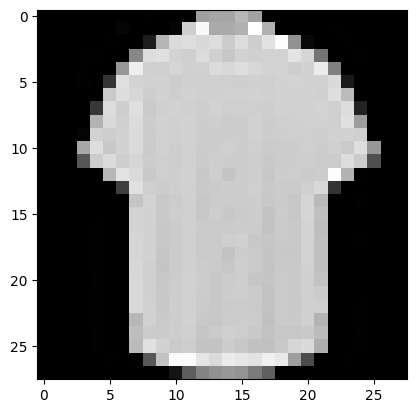

Label: 6 (labels_map[int(label)])


In [4]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label} (labels_map[int(label)])")

## 2. 세 가지 모델 정의

세 모델의 공통 구조는 다음과 같습니다.

$$784 \rightarrow 256 \rightarrow 64 \rightarrow 32 \rightarrow 10$$

28×28 이미지를 784차원 벡터로 펼친 뒤 세 개의 hidden layer와 ReLU를 거쳐 10개 class score를 만듭니다. 기본 모델은 약 22만 개의 학습 가능한 parameter를 갖습니다.

- **Net**: 완전연결층과 ReLU만 사용
- **NetBN**: 첫 두 완전연결층 뒤에 BatchNorm 추가
- **NetDO**: 첫 두 ReLU 뒤에 Dropout 추가

각 코드에서 정규화 층이 activation의 어느 위치에 적용되는지 비교해 보세요.

> **중요한 구현 주의점**: 세 모델은 마지막에 `softmax`를 적용하지만, PyTorch의 `CrossEntropyLoss`는 softmax 이전의 **raw logits**를 입력으로 기대합니다. 실제 코드에서는 마지막 `F.softmax(...)`를 제거하고 `self.fc4(x)`를 그대로 반환하는 것이 올바른 조합입니다. 여기서는 원본 코드를 유지하고 결과 해석 시 이 점을 고려합니다.


### 기본 MLP

`torch.flatten(x, 1)`은 batch 축은 유지하고 `(1, 28, 28)`을 길이 784의 벡터로 펼칩니다. 각 hidden layer에는 ReLU가 적용됩니다.

$$\mathrm{ReLU}(z)=\max(0,z)$$

마지막 10개 출력은 각 FashionMNIST class에 대응합니다. 분류에서는 이 값을 logits로 두고 가장 큰 값을 가진 class를 예측값으로 선택합니다.


In [5]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 2**8)
        self.fc2 = nn.Linear(2**8, 2**6)
        self.fc3 = nn.Linear(2**6, 2**5)
        self.fc4 = nn.Linear(2**5, 10)

    def forward(self, x):
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        x = F.softmax(x, dim=1)
        return x

### Batch Normalization을 추가한 MLP

`Linear → BatchNorm → ReLU` 순서로 첫 두 hidden layer를 구성합니다. `BatchNorm1d(256)`과 `BatchNorm1d(64)`의 숫자는 정규화할 feature 수와 일치해야 합니다.

BatchNorm은 학습 가능한 $\gamma$, $\beta$를 추가하므로 parameter 수가 조금 늘어나며, 학습 parameter 외에도 평가 시 사용할 running mean과 running variance를 buffer로 유지합니다.


In [6]:
class NetBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 2**8)
        self.bn1 = nn.BatchNorm1d(2**8)
        self.fc2 = nn.Linear(2**8, 2**6)
        self.bn2 = nn.BatchNorm1d(2**6)
        self.fc3 = nn.Linear(2**6, 2**5)
        self.fc4 = nn.Linear(2**5, 10)

    def forward(self, x):
        # same as torch.flatten(x,1)
        x = x.view(x.size(0), -1)
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        x = F.softmax(x, dim=1)
        return x

### Dropout을 추가한 MLP

`Linear → ReLU → Dropout` 순서로 첫 두 hidden layer를 구성합니다. Dropout은 학습 가능한 parameter를 추가하지 않습니다.

`p`는 **남길 확률이 아니라 제거할 확률**입니다. 따라서 `p=0.8`이면 평균적으로 첫 hidden unit의 20%만 남습니다. 너무 큰 `p`는 regularization을 강화하지만 정보가 과도하게 사라져 학습이 느려질 수 있습니다.


In [7]:
class NetDO(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 2**8)
        self.fc2 = nn.Linear(2**8, 2**6)
        self.fc3 = nn.Linear(2**6, 2**5)
        self.fc4 = nn.Linear(2**5, 10)
        self.dropout1 = nn.Dropout(p=0.8)
        self.dropout2 = nn.Dropout(p=0.5)

    def forward(self, x):
        # same as x.view(x.size(0), -1)
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        x = F.softmax(x, dim=1)
        return x

## 3. 학습 설정

세 모델에 같은 손실함수, optimizer, learning-rate scheduler를 사용합니다.

- **CrossEntropyLoss**: 다중 분류에서 정답 class의 확률이 높아지도록 학습합니다.
- **Adam**: parameter별 적응적 learning rate를 사용하는 optimizer입니다.
- **StepLR**: 지정한 epoch 간격마다 learning rate를 `gamma`배 합니다.

가능한 한 모델 외의 조건을 동일하게 두어야 성능 차이를 BatchNorm 또는 Dropout의 효과로 해석할 수 있습니다.


### Epoch 수와 device

`device`는 CUDA GPU가 있으면 `cuda:0`, 없으면 CPU를 선택합니다. 모델과 입력 tensor가 반드시 같은 device에 있어야 연산할 수 있습니다.

이 실습은 실행 시간을 줄이기 위해 5 epoch만 학습합니다. 따라서 곡선이 아직 수렴하지 않았을 수 있으며, 장기적인 과적합 억제 효과를 비교하기에는 짧을 수 있습니다.


In [8]:
num_epochs = 5   # 발표용 (원본 20)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda:0


### 손실함수·optimizer·scheduler

각 모델은 서로 다른 parameter를 가지므로 optimizer도 모델별로 따로 생성합니다. 세 optimizer의 초기 learning rate는 모두 `0.001`입니다.

`StepLR(step_size=5, gamma=0.8)`은 5 epoch마다 learning rate를 80%로 줄입니다. 그러나 현재 전체 학습도 5 epoch이므로 감소는 마지막 epoch 뒤에 일어나고, 실제 parameter update에는 사용되지 않습니다. scheduler의 효과를 보려면 5 epoch보다 더 오래 학습해야 합니다.


In [9]:
net_nn, net_bn, net_do = Net(), NetBN(), NetDO()
criterion = nn.CrossEntropyLoss()

optimizer_nn = optim.Adam(net_nn.parameters(), lr=0.001)
optimizer_bn = optim.Adam(net_bn.parameters(), lr=0.001)
optimizer_do = optim.Adam(net_do.parameters(), lr=0.001)

scheduler_nn = optim.lr_scheduler.StepLR(optimizer_nn, step_size=5, gamma=0.8)
scheduler_bn = optim.lr_scheduler.StepLR(optimizer_bn, step_size=5, gamma=0.8)
scheduler_do = optim.lr_scheduler.StepLR(optimizer_do, step_size=5, gamma=0.8)

### 학습 및 평가 함수

각 epoch는 다음 순서로 진행됩니다.

1. `net.train()`으로 학습 모드 설정
2. mini-batch마다 forward → loss → backward → parameter update
3. scheduler로 learning rate 갱신
4. `torch.no_grad()`와 `net.eval()`로 평가
5. epoch 평균 train/test loss와 test accuracy 기록

`train()`과 `eval()` 전환은 특히 중요합니다.

| Layer | `train()` | `eval()` |
|---|---|---|
| BatchNorm | 현재 mini-batch의 평균·분산 사용, running statistics 갱신 | 누적된 running mean·variance 사용 |
| Dropout | 확률 `p`로 activation을 제거 | 모든 activation 사용 |

> 이 코드의 `test_data`는 매 epoch 성능을 확인하는 데 사용되므로 엄밀히는 validation set처럼 쓰이고 있습니다. 최종 성능을 공정하게 보고하려면 train에서 validation을 별도로 나누고, 공식 test set은 모델 선택이 끝난 뒤 한 번만 평가해야 합니다.


### 코드 흐름 자세히 보기

학습 단계에서는 각 mini-batch에 대해 다음 연산이 일어납니다.

```text
입력 이동 → gradient 초기화 → forward → loss 계산
→ backward로 gradient 계산 → optimizer로 parameter 갱신
```

`running_loss`와 `test_loss`는 batch별 loss의 평균을 기록합니다. 각 batch의 크기가 거의 같으므로 간단한 비교에는 충분하지만, 마지막 batch 크기가 다를 수 있어 정확한 sample 평균을 구하려면 loss에 batch 크기를 곱해 누적한 뒤 전체 sample 수로 나누는 방법이 더 엄밀합니다.

#### 현재 코드의 두 가지 주의점

- 모델 출력이 이미 softmax 확률인데 `CrossEntropyLoss`에 전달됩니다. 이 손실은 내부에서 `log_softmax`를 적용하므로 raw logits를 전달해야 합니다.
- `outputs`가 확률이므로 `torch.exp(outputs)`는 확률을 다시 지수화하는 연산입니다. class 순위는 유지되어 accuracy가 우연히 같지만, 의미 있는 확률 변환은 아닙니다. logits를 반환한 뒤 `outputs.argmax(dim=1)`을 쓰는 것이 명확합니다.

마지막에는 `state_dict()`만 `.pth` 파일로 저장합니다. 재학습을 이어가려면 optimizer와 scheduler 상태도 함께 저장할 수 있습니다.


In [10]:
def train(net, optimizer, scheduler, path_name):

    train_losses, test_losses = [], []

    for epoch in range(num_epochs):  # loop over the dataset multiple times

        # set train mode
        net.train()

        # training
        running_loss = 0.0

        for inputs, labels in train_dataloader:

            inputs, labels = inputs.to(device), labels.to(device)

            # zero the parameter gradients
            optimizer.zero_grad()

            outputs = net(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        # adjust learning rate with scheduler
        scheduler.step()


        # evaluation(validation)
        test_loss = 0.0
        accuracy = 0.0

        # turn off grardients for validation
        with torch.no_grad():

            # set evaluation (test) mode
            net.eval()

            for inputs, labels in test_dataloader:

                inputs, labels = inputs.to(device), labels.to(device)

                outputs = net(inputs)

                test_loss += criterion(outputs, labels)

                # 로그 확률에 지수 적용
                ps = torch.exp(outputs)

                # topk는 k번째로 큰 숫자를 찾아내는 것
                # dim=1 는 dimension을 의미
                top_p, top_class = ps.topk(1, dim=1)


                # labels를 top_class와 똑같은 형태로 만든다음에, 얼마나 같은게 있는지 확인한다.
                equals = top_class == labels.view(*top_class.shape)


                # equals를 float으로 바꾸고 평균 정확도를 구한다.
                accuracy += torch.mean(equals.type(torch.FloatTensor))


        test_accuracy = accuracy / len(test_dataloader)

        current_train_loss = running_loss / len(train_dataloader)
        current_test_loss = test_loss / len(test_dataloader)

        train_losses.append(current_train_loss)
        test_losses.append(current_test_loss.detach().cpu().numpy())

        print(
            f"Epoch: {epoch+1} / {num_epochs}..",
            "Training Loss: {:.5f}..  ".format(current_train_loss),
            "Test Loss: {:.5f}..  ".format(current_test_loss),
            "Test Accuracy: {:.3f}".format(test_accuracy)

        )

    # save trained model
    PATH = f'./{path_name}.pth'
    torch.save(net.state_dict(), PATH)

    return train_losses, test_losses

## 4. 세 모델 학습 및 비교

각 모델을 동일한 함수로 학습한 뒤 train loss와 evaluation loss를 비교합니다. 일반적으로 다음 패턴을 살펴봅니다.

- train loss와 evaluation loss가 함께 감소: 학습과 일반화가 모두 개선 중
- train loss는 감소하지만 evaluation loss는 증가: 과적합 가능성
- 두 loss가 모두 높고 감소가 작음: underfitting 또는 학습 부족 가능성

> 현재 코드는 random seed를 고정하지 않고 모델을 각각 새로 초기화합니다. 작은 성능 차이는 정규화 기법보다 초기화와 mini-batch 순서의 우연한 차이일 수 있으므로, 엄밀한 비교에서는 여러 seed로 반복해 평균과 표준편차를 보고해야 합니다.

### (1) 기본 모델: 규제 없음

추가 정규화 없이 완전연결층과 ReLU만 사용한 기준 모델입니다. 이후 두 모델이 더 안정적으로 수렴하거나 evaluation loss를 낮추는지 판단하는 기준이 됩니다.


기본 모델을 선택한 device로 옮긴 뒤 학습합니다. 반환되는 두 리스트에는 epoch별 평균 train loss와 evaluation loss가 저장됩니다.


In [11]:
net_nn = net_nn.to(device)
train_loss_nn, test_loss_nn = train(net_nn, optimizer_nn, scheduler_nn, 'FMNIST_nn')

Epoch: 1 / 5.. Training Loss: 1.73327..   Test Loss: 1.70284..   Test Accuracy: 0.758
Epoch: 2 / 5.. Training Loss: 1.68584..   Test Loss: 1.68625..   Test Accuracy: 0.775
Epoch: 3 / 5.. Training Loss: 1.67379..   Test Loss: 1.68193..   Test Accuracy: 0.779
Epoch: 4 / 5.. Training Loss: 1.66737..   Test Loss: 1.67167..   Test Accuracy: 0.789
Epoch: 5 / 5.. Training Loss: 1.66386..   Test Loss: 1.66755..   Test Accuracy: 0.792


기본 모델의 두 곡선 사이 간격을 확인합니다. train loss가 계속 낮아지는데 evaluation loss가 반등한다면 과적합 신호일 수 있습니다. 단, 5개 점만으로 추세를 확정하기는 어렵습니다.


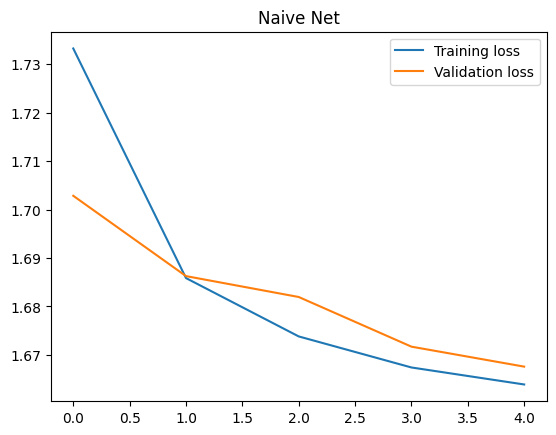

In [12]:
plt.plot(train_loss_nn, label='Training loss')
plt.plot(test_loss_nn, label='Validation loss')
plt.legend(); plt.title('Naive Net'); plt.show()

### (2) Batch Normalization

BatchNorm은 mini-batch에서 각 feature의 평균과 분산을 계산해 activation을 정규화한 뒤, 학습 가능한 scale $\gamma$와 shift $\beta$를 적용합니다.

$$\hat{x}=\frac{x-\mu_B}{\sqrt{\sigma_B^2+\epsilon}}, \qquad y=\gamma\hat{x}+\beta$$

이 과정은 layer별 activation scale을 안정화하고 gradient 흐름을 개선해 더 큰 learning rate나 빠른 수렴을 가능하게 할 수 있습니다. mini-batch 통계가 약간의 noise를 만들기 때문에 부수적인 regularization 효과가 나타나기도 합니다.

> BatchNorm의 효과를 단순히 “internal covariate shift를 제거한다”로만 설명하는 것은 현재 관점에서는 충분하지 않습니다. 실제로는 loss landscape와 optimization을 더 매끄럽게 만드는 효과 등 여러 설명이 함께 논의됩니다.


BatchNorm 모델도 같은 절차로 학습합니다. 작은 mini-batch에서는 평균과 분산 추정이 noisy할 수 있으므로 `batch_size` 역시 성능에 영향을 줍니다.


In [13]:
net_bn = net_bn.to(device)
train_loss_bn, test_loss_bn = train(net_bn, optimizer_bn, scheduler_bn, 'FMNIST_bn')

Epoch: 1 / 5.. Training Loss: 1.66924..   Test Loss: 1.62370..   Test Accuracy: 0.840
Epoch: 2 / 5.. Training Loss: 1.61577..   Test Loss: 1.62018..   Test Accuracy: 0.843
Epoch: 3 / 5.. Training Loss: 1.60573..   Test Loss: 1.60443..   Test Accuracy: 0.857
Epoch: 4 / 5.. Training Loss: 1.59656..   Test Loss: 1.60029..   Test Accuracy: 0.860
Epoch: 5 / 5.. Training Loss: 1.59332..   Test Loss: 1.60728..   Test Accuracy: 0.853


기본 모델과 비교해 초반 loss가 더 빠르게 감소하는지, 곡선의 진동이 줄어드는지 살펴보세요. BatchNorm이 항상 더 낮은 최종 loss를 보장하는 것은 아닙니다.


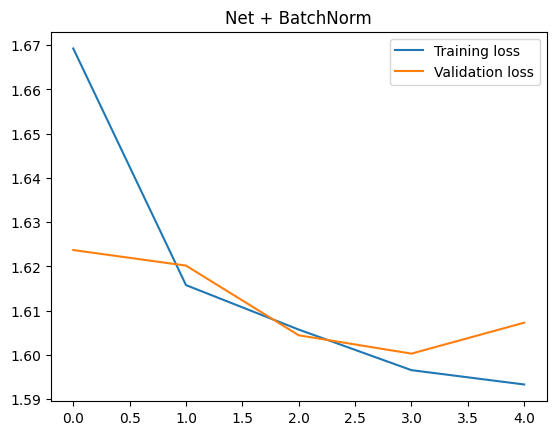

In [14]:
plt.plot(train_loss_bn, label='Training loss')
plt.plot(test_loss_bn, label='Validation loss')
plt.legend(); plt.title('Net + BatchNorm'); plt.show()

### (3) Dropout

Dropout은 학습할 때 각 activation을 독립적으로 확률 `p`만큼 0으로 만듭니다. PyTorch는 남은 activation을 자동으로 $1/(1-p)$배 하므로 평가 모드에서 별도의 크기 조정이 필요 없습니다.

$$\tilde{h}=\frac{m\odot h}{1-p}, \qquad m_i\sim\mathrm{Bernoulli}(1-p)$$

여기서 `dropout1(p=0.8)`은 첫 hidden activation의 **80%를 제거**한다는 뜻입니다. 매우 강한 설정이므로 5 epoch만 학습하면 train loss가 높게 남아 underfitting처럼 보일 수 있습니다. `p=0.5`는 두 번째 hidden activation의 절반을 제거합니다.

학습 중에는 매 forward pass마다 서로 다른 subnet을 사용하는 효과가 있고, 평가 시에는 전체 neuron을 사용해 일종의 ensemble과 비슷한 효과를 냅니다.


Dropout 모델을 학습합니다. 학습 모드에서는 매 mini-batch마다 일부 activation이 제거되므로 train loss가 다른 모델보다 높고 noisy하게 나타나는 것이 자연스러울 수 있습니다.


In [15]:
net_do = net_do.to(device)
train_loss_do, test_loss_do = train(net_do, optimizer_do, scheduler_do, 'FMNIST_do')

Epoch: 1 / 5.. Training Loss: 1.87307..   Test Loss: 1.70368..   Test Accuracy: 0.758
Epoch: 2 / 5.. Training Loss: 1.75576..   Test Loss: 1.68885..   Test Accuracy: 0.769
Epoch: 3 / 5.. Training Loss: 1.73844..   Test Loss: 1.68173..   Test Accuracy: 0.778
Epoch: 4 / 5.. Training Loss: 1.73165..   Test Loss: 1.67820..   Test Accuracy: 0.782
Epoch: 5 / 5.. Training Loss: 1.72178..   Test Loss: 1.66626..   Test Accuracy: 0.795


Dropout은 평가 모드에서 비활성화됩니다. 따라서 train loss는 dropout이 켜진 더 어려운 조건에서, evaluation loss는 dropout이 꺼진 조건에서 계산됩니다. 그 결과 evaluation loss가 train loss보다 낮게 나타나도 반드시 오류는 아닙니다.


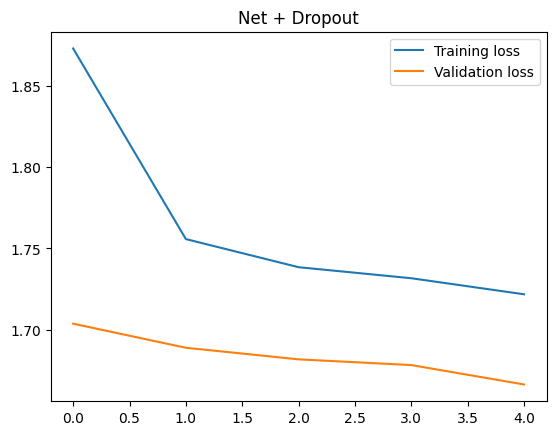

In [16]:
plt.plot(train_loss_do, label='Training loss')
plt.plot(test_loss_do, label='Validation loss')
plt.legend(); plt.title('Net + Dropout'); plt.show()

### 세 모델의 evaluation loss 비교

한 그래프에 세 모델의 evaluation loss를 표시해 수렴 속도와 최종 loss를 비교합니다. 다음 질문을 중심으로 해석해 보세요.

- BatchNorm 모델은 초반에 더 빠르고 안정적으로 감소하는가?
- Dropout 모델은 train loss가 높더라도 evaluation loss의 증가를 억제하는가?
- 단 5 epoch의 결과가 충분히 수렴한 상태인가?
- loss 차이가 실제 accuracy 차이와도 일치하는가?

한 번의 실행만으로 일반적인 우열을 결론내리기보다, 여러 seed와 충분한 epoch에서 반복하는 것이 좋습니다.


이 그래프는 세 모델의 evaluation loss만 겹쳐 표시합니다. loss뿐 아니라 accuracy와 실행별 분산도 함께 비교하면 일반화 성능을 더 균형 있게 평가할 수 있습니다.


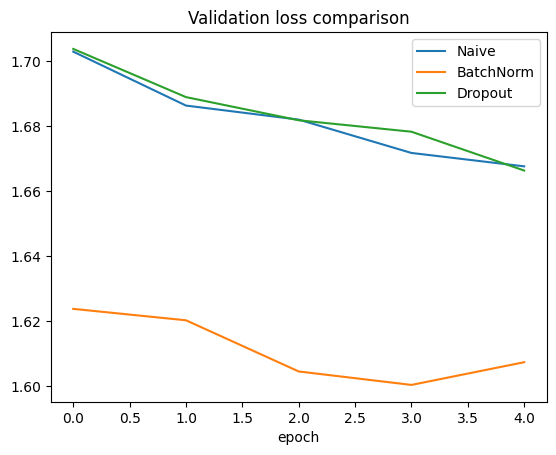

In [17]:
plt.plot(test_loss_nn, label='Naive')
plt.plot(test_loss_bn, label='BatchNorm')
plt.plot(test_loss_do, label='Dropout')
plt.legend(); plt.title('Validation loss comparison'); plt.xlabel('epoch'); plt.show()

## 정리

- **과적합**은 학습 데이터에는 잘 맞지만 새로운 데이터에서 성능이 떨어지는 현상입니다.
- **Batch Normalization**은 mini-batch 통계로 activation을 정규화해 학습을 안정화하며, 부수적으로 일반화에 도움이 될 수 있습니다.
- **Dropout**은 학습 중 activation을 무작위로 제거해 특정 feature 조합에 지나치게 의존하는 것을 막습니다.
- 두 기법은 모두 `train()`과 `eval()` 모드에서 동작이 달라지므로 평가 전 모드 전환이 필수입니다.
- 모델 비교에서는 구조 이외의 조건을 통제하고 train loss뿐 아니라 validation loss와 accuracy를 함께 봐야 합니다.

### 이 노트북의 구현상 체크포인트

1. `CrossEntropyLoss`에는 softmax 확률이 아니라 raw logits를 입력하는 것이 올바릅니다.
2. 평가 시 `torch.exp(outputs)`는 필요하지 않으며, `outputs.argmax(dim=1)`로 예측 class를 구할 수 있습니다.
3. 공식 test set을 epoch마다 조회하지 않도록 validation set을 별도로 두는 것이 좋습니다.
4. random seed와 데이터 분할을 고정해야 모델 간 비교의 재현성이 높아집니다.
5. 여러 모델을 이어서 학습할 때 optimizer가 해당 모델의 parameter를 참조하는지 확인해야 합니다.


## 확장 실습

1. 세 모델에서 마지막 `softmax`를 제거하고 학습 결과가 어떻게 달라지는지 확인해 보세요.
2. Dropout 확률을 0.2, 0.5, 0.8로 바꾸어 underfitting과 overfitting의 변화를 비교해 보세요.
3. 기본 모델의 Adam에 `weight_decay`를 추가해 L2 regularization과 비교해 보세요.
4. `num_epochs=20`으로 늘리고 early stopping 기준을 설계해 보세요.
5. train/validation/test를 분리하고 여러 random seed의 평균 accuracy를 표로 정리해 보세요.
